# RAG evaluation — curriculum retrieval and activity generation

The figures behind the model decisions in UC3 (generate) and UC5 (retrieve). Every number is read
from `backend/evals/results/*.json`, so re-running the harness and re-running this notebook keeps
the slides and the evidence in step.

**Read §3 before putting §2 on a slide.** The generator comparison looks like a result and is not
one: one model's run-to-run swing is more than twice the gap between the two models.

| Section | Question | Answer status |
|---|---|---|
| §2 | Which generator is more faithful? | **inconclusive** — variance exceeds the difference |
| §4 | Which embedding model ranks better? | measured — `nomic-embed-text`, on all five metrics |
| §5 | Which separates junk from real queries? | measured — `gemini-embedding-001`, by 21× |

The full write-up, including the parts that are argument rather than measurement, is
`docs/MODEL_EVALUATION.md`.

> **Regenerating the inputs.** `backend/evals/results/` is gitignored (the RAGAS files hold full
> prompts and completions). Recreate it with, from `backend/`:
> ```
> python -m evals.run_retrieval_eval          # §4, §5   — free, deterministic
> python -m evals.run_ragas --generator gemini # §2       — costs money, non-deterministic
> ```

In [1]:
import json, pathlib, sys
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# notebooks/ is one level below the repo root — same resolution the clustering notebook uses.
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
RESULTS = ROOT / "backend" / "evals" / "results"
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(exist_ok=True)

def load(stem):
    """Read one harness output. Fails loudly rather than plotting a hardcoded fallback."""
    path = RESULTS / f"{stem}.json"
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. This directory is gitignored — see the regeneration commands "
            f"at the top of this notebook."
        )
    return json.loads(path.read_text(encoding="utf-8"))

ragas = {
    "gemini-3.5-flash": load("ragas_gemini_claude-opus-5"),
    "claude-sonnet-5":  load("ragas_claude_claude-opus-5"),
}
retrieval = {
    "nomic-embed-text":     load("retrieval_ollama_nomic-embed-text-latest_hybrid_k3"),
    "gemini-embedding-001": load("retrieval_gemini_gemini-embedding-001_hybrid_k3"),
}

# Every run must score the SAME golden set, or the comparisons below are between different exams.
digests = {d["header"]["golden_digest"] for d in (*ragas.values(), *retrieval.values())}
assert len(digests) == 1, f"results span different golden sets: {digests}"

print(f"golden set   {digests.pop()}")
print(f"judge        {ragas['gemini-3.5-flash']['header']['judge']}")
print(f"corpus       {retrieval['nomic-embed-text']['header']['corpus_chunks']} chunks, "
      f"k={retrieval['nomic-embed-text']['header']['k']} hybrid")
print(f"cases        {retrieval['nomic-embed-text']['header']['golden_cases']} total, "
      f"{retrieval['nomic-embed-text']['summary']['n_scored_cases']} scored in-domain")

golden set   ffef2baba8fd
judge        claude-opus-5
corpus       264 chunks, k=3 hybrid
cases        28 total, 20 scored in-domain


## 1 — House style for the figures

Two series throughout, so two hues carry identity. They are checked for colour-vision deficiency
separation rather than chosen by eye: blue/orange is the one categorical pair that stays
distinguishable under protanopia, deuteranopia and tritanopia at this lightness.

Every figure is written to `notebooks/figures/` at 200 dpi — drop the PNGs straight into the deck.

In [2]:
BLUE, ORANGE = "#2a78d6", "#eb6834"      # series 1 / series 2
GREY, INK    = "#a3a29a", "#0b0b0b"
MUTED        = "#78776f"
GOOD, CRIT   = "#1baf7a", "#e34948"       # semantic only — never a third series

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def save(fig, name):
    """Write the PNG and say where it went, so the deck can be rebuilt from a filename."""
    out = FIGURES / f"{name}.png"
    fig.savefig(out, facecolor="white")
    print(f"wrote {out.relative_to(ROOT)}")

def label_bars(ax, bars, fmt="{:.3f}", bold=False):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015,
                fmt.format(b.get_height()), ha="center", va="bottom",
                fontsize=9.5, fontweight="bold" if bold else "normal",
                fontfamily="monospace", color=INK)

## 2 — RAGAS: the two generators side by side

The headline comparison, one run of each over the same 20 in-domain cases, judged by
`claude-opus-5`.

`context_recall` scoring identically for both is **the harness's own consistency check**, not a
coincidence: it measures retrieval, which does not change when the generator changes. If those two
bars ever differ, state is leaking between runs.

wrote notebooks\figures\ragas_generator_comparison.png


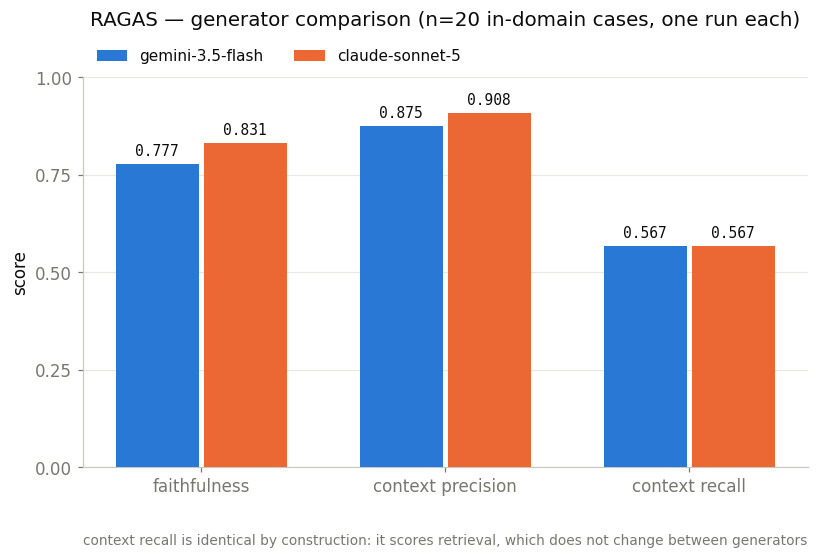

In [3]:
METRICS = [
    ("faithfulness",                              "faithfulness"),
    ("llm_context_precision_without_reference",   "context precision"),
    ("non_llm_context_recall",                    "context recall"),
]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
# GAP, not touching: width 0.34 at ±0.18 leaves 0.02 of surface between the pair, so the two
# bars read as two marks rather than one two-tone block.
width, xs = 0.34, range(len(METRICS))

for offset, (name, colour) in zip((-0.18, 0.18),
                                  (("gemini-3.5-flash", BLUE), ("claude-sonnet-5", ORANGE))):
    values = [ragas[name]["summary"][key] for key, _ in METRICS]
    bars = ax.bar([x + offset for x in xs], values, width, label=name, color=colour, zorder=3)
    label_bars(ax, bars)

ax.set_xticks(list(xs)); ax.set_xticklabels([lbl for _, lbl in METRICS])
ax.set_ylim(0, 1.0); ax.yaxis.set_major_locator(MultipleLocator(0.25))
ax.set_ylabel("score"); ax.grid(axis="y", color="#e8e7e2", zorder=0)
ax.set_title("RAGAS — generator comparison (n=20 in-domain cases, one run each)", pad=34)
# Legend ABOVE the axes. Inside, it collided with the 0.908 value label — the tallest bar and the
# legend want the same corner.
ax.legend(frameon=False, ncols=2, fontsize=10,
          loc="lower left", bbox_to_anchor=(0, 1.0, 1, 0.1), mode=None)

# The note goes BELOW the axis, in axes coordinates. Placed inside the plot it printed over the
# bars, which is worse than not saying it.
ax.text(0.5, -0.20, "context recall is identical by construction: it scores retrieval, "
                    "which does not change between generators",
        transform=ax.transAxes, ha="center", fontsize=9, color=MUTED)

save(fig, "ragas_generator_comparison"); plt.show()

## 3 — Why §2 is not a result

Claude leads faithfulness by **0.055**. An earlier run of the *same* Gemini configuration scored
**0.9000** against 0.7767 here — a within-model swing of **0.123**, more than double the
between-model gap.

Generation is non-deterministic on both providers: Gemini's seed is best-effort and only when
explicitly passed, and Claude 5 exposes no seed parameter and rejects `temperature` outright. Every
run regenerates all 20 activities.

> **Do not report `claude-sonnet-5` as more faithful on this evidence.** Establishing that needs
> 5–10 runs per generator compared as distributions. `gemini-3.5-flash` was chosen **on cost** —
> an argument from absence of demonstrated difference, not a demonstration of equivalence.

wrote notebooks\figures\ragas_variance_vs_difference.png


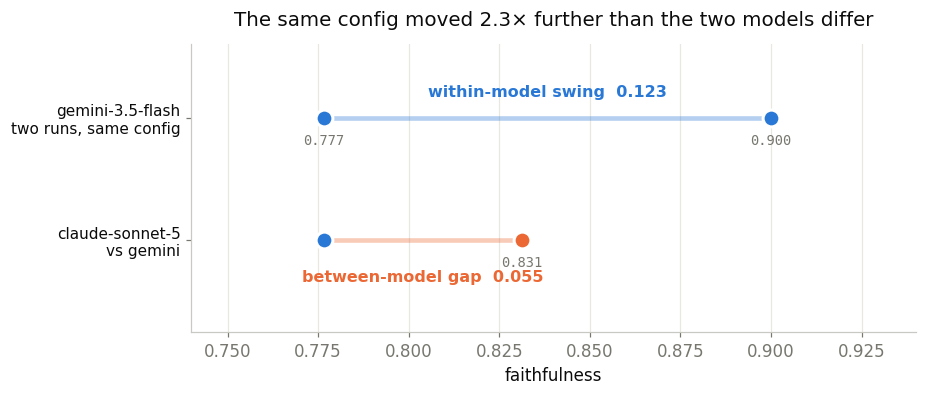


swing 0.1233  /  gap 0.0545  =  2.26x


In [4]:
# The 0.9000 is the one figure here NOT in the JSON: it is an earlier run of the same Gemini
# config, recorded in docs/MODEL_EVALUATION.md §7 and overwritten by the run that produced
# ragas_gemini_claude-opus-5.json. Kept explicit rather than hidden in a constant.
GEMINI_EARLIER_RUN = 0.9000

gem_now = ragas["gemini-3.5-flash"]["summary"]["faithfulness"]
claude  = ragas["claude-sonnet-5"]["summary"]["faithfulness"]
swing, gap = abs(GEMINI_EARLIER_RUN - gem_now), abs(claude - gem_now)

fig, ax = plt.subplots(figsize=(8.5, 3.4))

ax.hlines(1.0, gem_now, GEMINI_EARLIER_RUN, color=BLUE, lw=3, alpha=0.35, zorder=2)
ax.plot([gem_now, GEMINI_EARLIER_RUN], [1, 1], "o", ms=11, color=BLUE,
        mec="white", mew=2, zorder=3)
ax.text((gem_now + GEMINI_EARLIER_RUN)/2, 1.17, f"within-model swing  {swing:.3f}",
        ha="center", fontsize=10.5, fontweight="bold", color=BLUE)

ax.hlines(0.0, gem_now, claude, color=ORANGE, lw=3, alpha=0.35, zorder=2)
ax.plot([gem_now], [0], "o", ms=11, color=BLUE, mec="white", mew=2, zorder=3)
ax.plot([claude], [0], "o", ms=11, color=ORANGE, mec="white", mew=2, zorder=3)
ax.text((gem_now + claude)/2, -0.34, f"between-model gap  {gap:.3f}",
        ha="center", fontsize=10.5, fontweight="bold", color=ORANGE)

for x, y in ((gem_now, 1), (GEMINI_EARLIER_RUN, 1), (claude, 0)):
    ax.text(x, y - 0.22, f"{x:.3f}", ha="center", fontsize=9, color=MUTED, fontfamily="monospace")

ax.set_yticks([0, 1])
ax.set_yticklabels(["claude-sonnet-5\nvs gemini", "gemini-3.5-flash\ntwo runs, same config"],
                   fontsize=10, color=INK)
ax.set_ylim(-0.75, 1.6); ax.set_xlim(0.74, 0.94)
ax.set_xlabel("faithfulness"); ax.grid(axis="x", color="#e8e7e2", zorder=0)
ax.set_title(f"The same config moved {swing/gap:.1f}× further than the two models differ", pad=12)

save(fig, "ragas_variance_vs_difference"); plt.show()
print(f"\nswing {swing:.4f}  /  gap {gap:.4f}  =  {swing/gap:.2f}x")

## 4 — Retrieval: `nomic-embed-text` vs `gemini-embedding-001`

Unlike §2 this comparison **is** conclusive: retrieval is deterministic, so these numbers reproduce
exactly on re-run. The incumbent wins every ranking metric.

wrote notebooks\figures\retrieval_ranking_quality.png

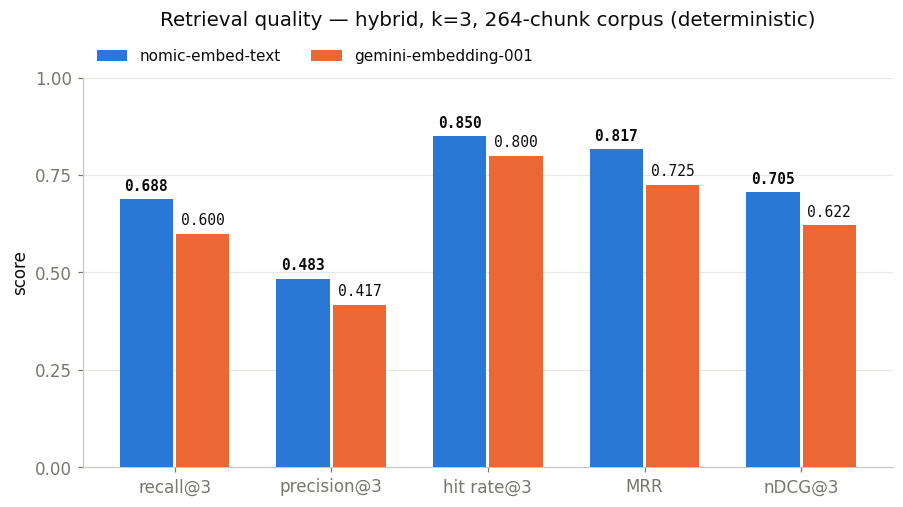


nomic-embed-text wins 5/5 ranking metrics


In [5]:
RETRIEVAL_METRICS = ["recall@3", "precision@3", "hit_rate@3", "mrr", "ndcg@3"]
PRETTY = {"recall@3": "recall@3", "precision@3": "precision@3", "hit_rate@3": "hit rate@3",
          "mrr": "MRR", "ndcg@3": "nDCG@3"}

fig, ax = plt.subplots(figsize=(9.5, 4.6))
width, xs = 0.34, range(len(RETRIEVAL_METRICS))

for offset, (name, colour) in zip((-0.18, 0.18),
                                  (("nomic-embed-text", BLUE), ("gemini-embedding-001", ORANGE))):
    values = [retrieval[name]["summary"][m] for m in RETRIEVAL_METRICS]
    bars = ax.bar([x + offset for x in xs], values, width, label=name, color=colour, zorder=3)
    label_bars(ax, bars, bold=(name == "nomic-embed-text"))

ax.set_xticks(list(xs)); ax.set_xticklabels([PRETTY[m] for m in RETRIEVAL_METRICS])
ax.set_ylim(0, 1.0); ax.yaxis.set_major_locator(MultipleLocator(0.25))
ax.set_ylabel("score"); ax.grid(axis="y", color="#e8e7e2", zorder=0)
ax.set_title("Retrieval quality — hybrid, k=3, 264-chunk corpus (deterministic)", pad=34)
ax.legend(frameon=False, ncols=2, fontsize=10, loc="lower left", bbox_to_anchor=(0, 1.0, 1, 0.1))

save(fig, "retrieval_ranking_quality"); plt.show()

wins = sum(retrieval["nomic-embed-text"]["summary"][m]
           > retrieval["gemini-embedding-001"]["summary"][m] for m in RETRIEVAL_METRICS)
print(f"\nnomic-embed-text wins {wins}/{len(RETRIEVAL_METRICS)} ranking metrics")

## 5 — The trade-off that actually decides it

Ranking is not the property carrying the risk. What stops an off-topic request reaching the model is
the **gap between the worst real query and the best junk query** — and there the winner flips.

Both junk ceilings are set by the same case, `junk_maths_lookalike`, phrased in the system's own
template: *"literacy activity targeting phonics 3.0/10 — long division and multiplying fractions"*.
That is the realistic failure mode: a therapist asking, in the system's own words, for something the
corpus does not cover.

This matters because the model's own refusal guardrail catches only **1 of 8** off-topic requests
(identically on both vendors, reproduced three times — `docs/MODEL_EVALUATION.md` §6). The
similarity gate is the only working defence.

wrote notebooks\figures\gate_junk_real_separation.png


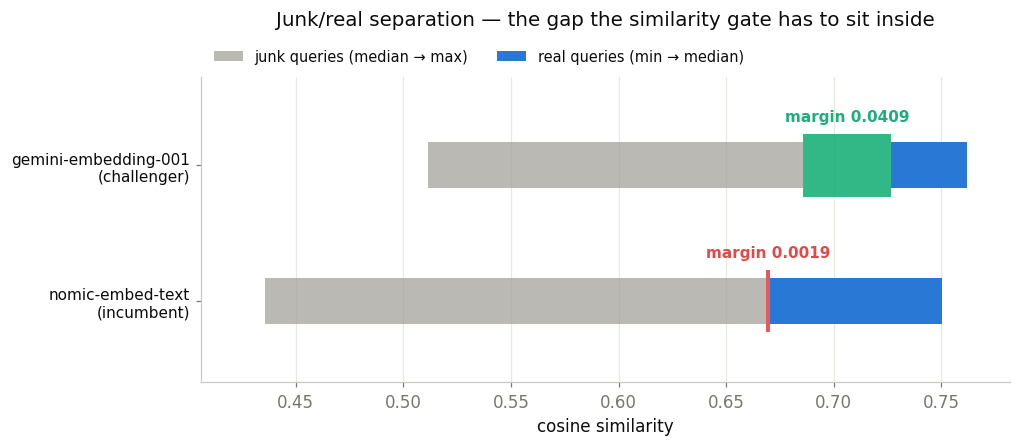


nomic  junk<=0.6686  real>=0.6705  margin 0.0019
gemini junk<=0.6859  real>=0.7268  margin 0.0409
gemini separates 21.6x wider


In [6]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))

rows = [("gemini-embedding-001", 1), ("nomic-embed-text", 0)]
for name, y in rows:
    g = retrieval[name]["gate"]
    ax.barh(y, g["junk_max"] - g["junk_median"], left=g["junk_median"],
            height=0.34, color=GREY, alpha=0.75, zorder=3,
            label="junk queries (median → max)" if y == 1 else None)
    ax.barh(y, g["real_median"] - g["real_min"], left=g["real_min"],
            height=0.34, color=BLUE, zorder=3,
            label="real queries (min → median)" if y == 1 else None)

    margin = g["real_min"] - g["junk_max"]
    colour = GOOD if margin > 0.02 else CRIT
    ax.barh(y, margin, left=g["junk_max"], height=0.46, color=colour, alpha=0.9, zorder=4)
    ax.annotate(f"margin {margin:.4f}",
                xy=(g["junk_max"] + margin/2, y + 0.30), ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=colour)

ax.set_yticks([0, 1]); ax.set_yticklabels(["nomic-embed-text\n(incumbent)",
                                           "gemini-embedding-001\n(challenger)"],
                                          fontsize=10, color=INK)
ax.set_ylim(-0.6, 1.65); ax.set_xlabel("cosine similarity")
# Pad the left so nomic's junk band (median 0.436, the smallest value here) does not start
# flush against the spine and read as clipped.
lo = min(d["gate"]["junk_median"] for d in retrieval.values())
hi = max(d["gate"]["real_median"] for d in retrieval.values())
ax.set_xlim(lo - 0.03, hi + 0.02)
ax.grid(axis="x", color="#e8e7e2", zorder=0)
ax.set_title("Junk/real separation — the gap the similarity gate has to sit inside", pad=34)
ax.legend(frameon=False, fontsize=9.5, ncols=2, loc="lower left", bbox_to_anchor=(0, 1.0, 1, 0.1))

save(fig, "gate_junk_real_separation"); plt.show()

n = retrieval["nomic-embed-text"]["gate"]; g = retrieval["gemini-embedding-001"]["gate"]
n_m = n["real_min"] - n["junk_max"]; g_m = g["real_min"] - g["junk_max"]
# 4 dp, not 2: nomic's junk ceiling and real floor both round to 0.67, which reads as a typo
# rather than as the finding.
print(f"\nnomic  junk<={n['junk_max']:.4f}  real>={n['real_min']:.4f}  margin {n_m:.4f}")
print(f"gemini junk<={g['junk_max']:.4f}  real>={g['real_min']:.4f}  margin {g_m:.4f}")
# 1 dp: this is 21.6, and `:.0f` rounds it to 22 — which would contradict the "21x" that
# docs/MODEL_EVALUATION.md reports (it floors).
print(f"gemini separates {g_m/n_m:.1f}x wider")

## 6 — Every figure in one table

The numbers as scored, for the appendix slide and for checking a chart against its source.

In [7]:
import pandas as pd

gen = pd.DataFrame({
    name: {
        "faithfulness":      d["summary"]["faithfulness"],
        "context precision": d["summary"]["llm_context_precision_without_reference"],
        "context recall":    d["summary"]["non_llm_context_recall"],
        "refusal rate":      d["summary"]["refusal_rate"],
    } for name, d in ragas.items()
}).round(4)

ret = pd.DataFrame({
    name: {**{PRETTY[m]: d["summary"][m] for m in RETRIEVAL_METRICS},
           "junk max":  d["gate"]["junk_max"],
           "real min":  d["gate"]["real_min"],
           "margin":    d["gate"]["real_min"] - d["gate"]["junk_max"]}
    for name, d in retrieval.items()
}).round(4)

display(gen, ret)
gen.to_csv(FIGURES / "generator_summary.csv")
ret.to_csv(FIGURES / "retrieval_summary.csv")
print(f"wrote {(FIGURES / 'generator_summary.csv').relative_to(ROOT)} and retrieval_summary.csv")

,gemini-3.5-flash,claude-sonnet-5
faithfulness,0.7767,0.8312
context precision,0.8750,0.9083
context recall,0.5667,0.5667
refusal rate,0.1250,0.1250


,nomic-embed-text,gemini-embedding-001
recall@3,0.6875,0.6000
precision@3,0.4833,0.4167
hit rate@3,0.8500,0.8000
MRR,0.8167,0.7250
nDCG@3,0.7053,0.6216
junk max,0.6686,0.6859
real min,0.6705,0.7268
margin,0.0019,0.0409


wrote notebooks\figures\generator_summary.csv and retrieval_summary.csv
